# **WHAT IS THE PROBLEM ABOUT?**

Apples are one of the most important temperate fruit crops in the world. Foliar (leaf) diseases pose a major threat to the overall productivity and quality of apple orchards. The current process for disease diagnosis in apple orchards is based on manual scouting by humans, which is time-consuming and expensive.

Although computer vision-based models have shown promise for plant disease identification, there are some limitations that need to be addressed. Large variations in visual symptoms of a single disease across different apple cultivars, or new varieties that originated under cultivation, are major challenges for computer vision-based disease identification. These variations arise from differences in natural and image capturing environments, for example, leaf color and leaf morphology, the age of infected tissues, non-uniform image background, and different light illumination during imaging etc.

Plant Pathology 2020-FGVC7 challenge competition had a pilot dataset of 3,651 RGB images of foliar disease of apples. For Plant Pathology 2021-FGVC8, we have significantly increased the number of foliar disease images and added additional disease categories. This year’s dataset contains approximately 23,000 high-quality RGB images of apple foliar diseases, including a large expert-annotated disease dataset. This dataset reflects real field scenarios by representing non-homogeneous backgrounds of leaf images taken at different maturity stages and at different times of day under different focal camera settings.

# Specific Objectives

The main objective of the competition is to develop machine learning-based models to accurately classify a given leaf image from the test dataset to a particular disease category, and to identify an individual disease from multiple disease symptoms on a single leaf image.

# Resources

I thank Kaggle for providing the dataset and Data without whom this wouldn't have been possible. Also I would like to thank Ankur Singh for this amazing dataset as without it , it would have taken hours and hours to train the below mentioned model [Ankur Singh](http://https://www.kaggle.com/ankursingh12/resized-plant2021).

# Importing All the Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import tensorflow.keras as keras
import PIL
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from tqdm import tqdm
import tensorflow_addons as tfa
import random
from sklearn.preprocessing import MultiLabelBinarizer
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import keras
from keras.preprocessing import image
from keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, smart_resize
from keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation
from keras.constraints import maxnorm
from keras.layers.convolutional import Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
import cv2
from PIL import Image
from keras.preprocessing.image import load_img, img_to_array
from keras.models import load_model
from keras.metrics import AUC
import matplotlib.pyplot as plt
import tensorflow as tf 
import random as rn
import numpy as np
import os

from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications import ResNet50

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense,Dropout,Flatten
from tensorflow.keras.layers import MaxPooling2D,GlobalAveragePooling2D,BatchNormalization,Activation
from tensorflow import keras
from keras import backend as K
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import tensorflow as tf
import logging
logging.basicConfig()
import struct
from tensorflow.keras.layers import Dense, Activation, Conv2D, Flatten, Dropout, Input, BatchNormalization
%matplotlib inline
import IPython.core.display         
# setup output image format (Chrome works best)
IPython.core.display.set_matplotlib_formats("svg")
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import sklearn
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer,OneHotEncoder
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import backend as K
from tensorflow.keras.applications import ResNet50V2

%matplotlib inline

# Performing EDA And Understanding Our Data Better

In [2]:
train_dir= '../input/plant-pathology-2021-fgvc8/train_images'
test_dir =  '../input/plant-pathology-2021-fgvc8/test_images'
train = pd.read_csv('../input/plant-pathology-2021-fgvc8/train.csv')

In [3]:
train.head

<bound method NDFrame.head of                       image                           labels
0      800113bb65efe69e.jpg                          healthy
1      8002cb321f8bfcdf.jpg  scab frog_eye_leaf_spot complex
2      80070f7fb5e2ccaa.jpg                             scab
3      80077517781fb94f.jpg                             scab
4      800cbf0ff87721f8.jpg                          complex
...                     ...                              ...
18627  fffb900a92289a33.jpg                          healthy
18628  fffc488fa4c0e80c.jpg                             scab
18629  fffc94e092a59086.jpg                             rust
18630  fffe105cf6808292.jpg          scab frog_eye_leaf_spot
18631  fffe472a0001bd25.jpg                          healthy

[18632 rows x 2 columns]>

**We consider the two columns only which are images and the labels because that's all  we need to perform EDA and train the model.** 

In [4]:
#dup = pd.DataFrame(dup,columns = ['dup1','dup2'])
train = pd.DataFrame(train,columns = ['image','labels'])

# Let Us Find Out the Different Types of Classes(Diseases)

In [5]:
train['labels'].value_counts()

scab                               4826
healthy                            4624
frog_eye_leaf_spot                 3181
rust                               1860
complex                            1602
powdery_mildew                     1184
scab frog_eye_leaf_spot             686
scab frog_eye_leaf_spot complex     200
frog_eye_leaf_spot complex          165
rust frog_eye_leaf_spot             120
rust complex                         97
powdery_mildew complex               87
Name: labels, dtype: int64

# Frequency of Each Class

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


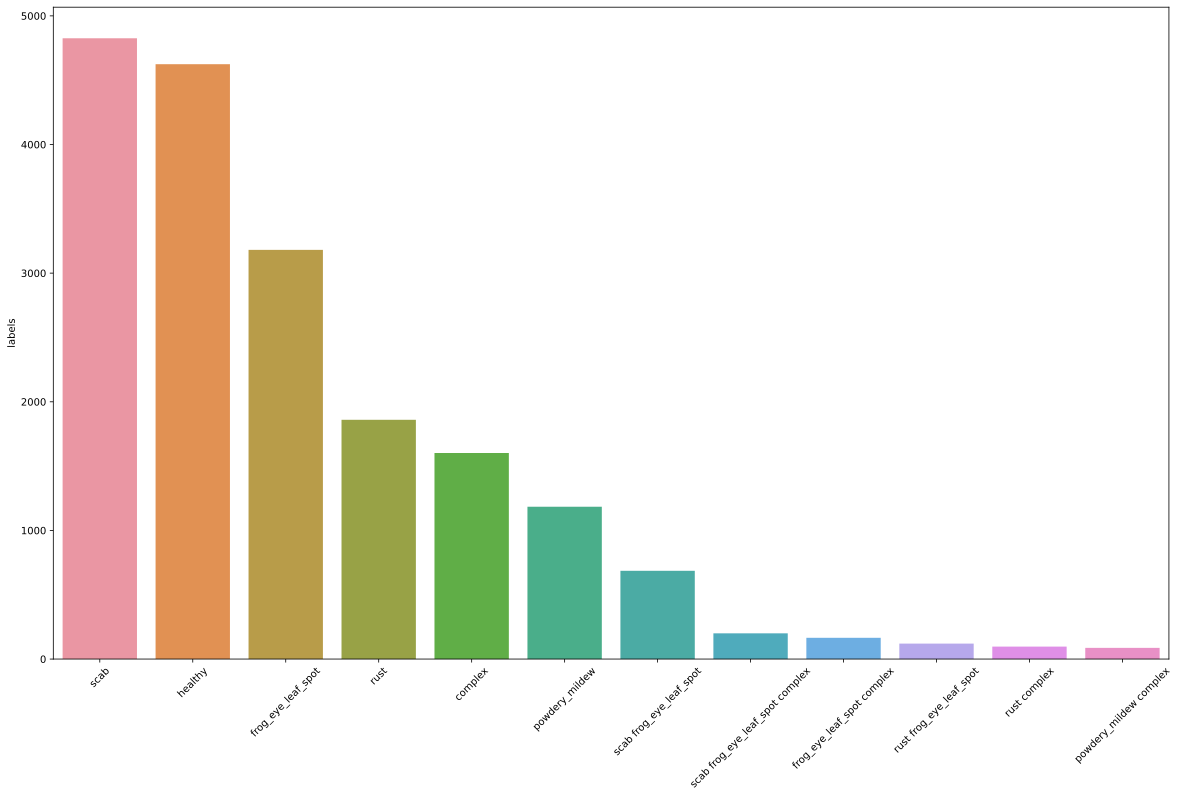

In [6]:
plt.figure(figsize=(20,12))
labels = sns.barplot(train.labels.value_counts().index,train.labels.value_counts())
for item in labels.get_xticklabels():
    item.set_rotation(45)

# Important Observation

**Look at the labels, does anything strike you ??
Some of the labels are mixture of one or more types !!! And thus the problem becomes Multilabel Problem**

So there are not 12 labels, its actually just 6 labels. 5 diseases:
**1. Rust 2.Scab 3.Complex 4.Frog eye leaf spot 5.Powdery Mildew  and Last Label is "Healthy"**
Now the most important thing is, as one image can have multiple diseases, that means this problem is Multi label classification problem. Many get confused betweeen multilabel and multiclass classification. if you are new to multilabel classification I would suggest going over this.
[Multilabel Classification](http://https://www.geeksforgeeks.org/an-introduction-to-multilabel-classification/)
So now we gotta process the labels. And then lets find out the actual frequencies of the labels.
We divide it based on " " or space character , in order to get the labels for each of the image

In [7]:
train['labels'] = train['labels'].apply(lambda s: s.split(' '))
train[:10]

,image,labels
0,800113bb65efe69e.jpg,[healthy]
1,8002cb321f8bfcdf.jpg,"[scab, frog_eye_leaf_spot, complex]"
2,80070f7fb5e2ccaa.jpg,[scab]
3,80077517781fb94f.jpg,[scab]
4,800cbf0ff87721f8.jpg,[complex]
5,800edef467d27c15.jpg,[healthy]
6,800f85dc5f407aef.jpg,[rust]
7,801d6dcd96e48ebc.jpg,[healthy]
8,801f78399a44e7af.jpg,[complex]
9,8021b94d437eb7d3.jpg,[healthy]


# **Preparing Our Model**

# Image Preprocessing Using Keras Image Data Generator
Those who want to know about Image Data Generator can look at this Documentation in order to get idea on what are the things we can perform [Keras Image Data Generator](http://https://keras.io/api/preprocessing/image/)

In [8]:
def add_gauss_noise(x,sigma2=0.05):
    return x+np.random.normal(0, sigma2, x.shape)

In [9]:
datagen = ImageDataGenerator(
    rotation_range = 10,#Performing Rotation
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    brightness_range = None,
    shear_range = 0.1,
    zoom_range = 0.1,
    rescale = 1./255,
    horizontal_flip=True,
    vertical_flip=True,
    
    validation_split= 0.1# We will split the training data into training and validation set in the ration 90:10
)
bsize  = 16 # Giving a batch size of 16

# Preprocessing the Training and Validation Data

In [10]:
train_data = datagen.flow_from_dataframe(
    train,
    directory = '../input/resized-plant2021/img_sz_512',# We are using the resized images otherwise it will take a lot of time to train 
    x_col = 'image',
    y_col = 'labels',
    subset="training",
    color_mode="rgb",
    target_size = (224,224),
    class_mode="categorical",
    batch_size=bsize,
    shuffle=False,
    seed=40,
)

Found 16769 validated image filenames belonging to 6 classes.


# Preparing the Validation Data

In [11]:
valid_data = datagen.flow_from_dataframe(
    train,
    directory = '../input/resized-plant2021/img_sz_512',
    x_col = 'image',
    y_col = 'labels',
    subset="validation",
    color_mode="rgb",
    target_size = (224,224),
    class_mode="categorical",
    batch_size=bsize,
    shuffle=False,
    seed=40,
)

Found 1863 validated image filenames belonging to 6 classes.


# Now we are Using Transfer Learning Model
**Here I used ResNet 50V2 , which was present in the Keras Library. It is a modified version of the famous ResNet 50 architecture. After Using ResNet 50v2 as a base we fine tune our model.**

In [12]:
from tensorflow.keras.preprocessing import image
import random

K.clear_session()
random.seed(4487); tf.random.set_seed(4487)

input_shape= (224,224,3)#Using the shape of (224,224)
# 
base_model = ResNet50V2(input_shape=input_shape, include_top=False,weights= "imagenet")

94674944/94668760 [==============================] - 1s 0us/step


In [13]:
from tensorflow.keras.layers import MaxPooling2D,GlobalAveragePooling2D,BatchNormalization,Activation
x = base_model.output
x = GlobalAveragePooling2D()(x)
#fully connected layer
x = Dense(64, activation='relu')(x)
x = Dense(16, activation='relu')(x)
# finally, the softmax for the classifier 
predictions = Dense(6, activation='softmax')(x)

# Let Us Look at out Model 

In [14]:
model = tf.keras.Model(inputs=base_model.input ,outputs = predictions)
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
conv1_pad (ZeroPadding2D)       (None, 230, 230, 3)  0           input_1[0][0]                    
__________________________________________________________________________________________________
conv1_conv (Conv2D)             (None, 112, 112, 64) 9472        conv1_pad[0][0]                  
__________________________________________________________________________________________________
pool1_pad (ZeroPadding2D)       (None, 114, 114, 64) 0           conv1_conv[0][0]                 
______________________________________________________________________________________________

# **Training Our Model And Let's Find out the Results**

In [19]:
from tensorflow.keras.models import Sequential, Model
from keras.metrics import Precision, Recall
model = tf.keras.Model(inputs=base_model.input ,outputs = predictions)
import tensorflow_addons as tfa
import keras 
f1 = tfa.metrics.F1Score(num_classes=6, average='macro')
model.compile(optimizer=keras.optimizers.SGD(lr=0.03, decay=1e-4, momentum=0.8, nesterov=True), 
              loss='binary_crossentropy', metrics=[f1,"accuracy", Precision(name='precision'), Recall(name='recall')])

accearlystop = keras.callbacks.EarlyStopping(
    monitor=f1,     # look at the validation loss tf2.0 accuracy
    min_delta=0.02,       # threshold to consider as no change
    patience=5,             # stop if  epochs with no change
    verbose=1, mode='max', restore_best_weights= True
)
lossearlystop = keras.callbacks.EarlyStopping(
    monitor='val_loss',     # look at the validation loss tf2.0 accuracy
    min_delta=0.02,       # threshold to consider as no change
    patience=5,             # stop if  epochs with no change
    verbose=1, mode='min', restore_best_weights= True
)
# callbacks_list = [earlystop]
lrschedule = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', 
                                 factor=0.05, patience=5, verbose=1)
callbacks_list = [lrschedule]
# callbacks_list = [accearlystop,lossearlystop]
#callbacks_list = []

history = model.fit_generator(
            train_data,  # data from generator
             #steps_per_epoch=1,    # should be number of batches per epoch
            epochs=25,
            callbacks=callbacks_list, 
            validation_data=valid_data, 
            #validation_steps = 1,
            verbose=True)



Epoch 1/25
1049/1049 [==============================] - 298s 279ms/step - loss: 0.1502 - f1_score: 0.8052 - accuracy: 0.8355 - precision: 0.8810 - recall: 0.7731 - val_loss: 0.1777 - val_f1_score: 0.7729 - val_accuracy: 0.7982 - val_precision: 0.8385 - val_recall: 0.7524
Epoch 2/25
1049/1049 [==============================] - 251s 240ms/step - loss: 0.1251 - f1_score: 0.8389 - accuracy: 0.8667 - precision: 0.9065 - recall: 0.8070 - val_loss: 0.1551 - val_f1_score: 0.7902 - val_accuracy: 0.8159 - val_precision: 0.8582 - val_recall: 0.7765
Epoch 3/25
1049/1049 [==============================] - 254s 242ms/step - loss: 0.1135 - f1_score: 0.8547 - accuracy: 0.8814 - precision: 0.9188 - recall: 0.8191 - val_loss: 0.1690 - val_f1_score: 0.8102 - val_accuracy: 0.8325 - val_precision: 0.8621 - val_recall: 0.7866
Epoch 4/25
1049/1049 [==============================] - 253s 241ms/step - loss: 0.1005 - f1_score: 0.8629 - accuracy: 0.8907 - precision: 0.9247 - recall: 0.8288 - val_loss: 0.1576 - v

In [20]:
model.evaluate(valid_data)

117/117 [==============================] - 27s 231ms/step - loss: 0.0932 - f1_score: 0.9026 - accuracy: 0.9184 - precision: 0.9480 - recall: 0.8812


[0.09322304278612137,
 0.9025999903678894,
 0.918411135673523,
 0.948023796081543,
 0.881227970123291]

# Plotting Our Performance for the model 

In [ ]:
accname = 'f1_score'

def plot_history(history): 
    fig, ax1 = plt.subplots()
    
    ax1.plot(history.history['loss'], 'r', label="training loss ({:.6f})".format(history.history['loss'][-1]))
    ax1.plot(history.history['val_loss'], 'r--', label="validation loss ({:.6f})".format(history.history['val_loss'][-1]))
    ax1.grid(True)
    ax1.set_xlabel('iteration')
    ax1.legend(loc="best", fontsize=9)    
    ax1.set_ylabel('loss', color='r')
    ax1.tick_params('y', colors='r')

    if accname in history.history:
        ax2 = ax1.twinx()

        ax2.plot(history.history[accname], 'b', label="training f1_score ({:.4f})".format(history.history[accname][-1]))
        ax2.plot(history.history['val_'+accname], 'b--', label="validation f1_score ({:.4f})".format(history.history['val_'+accname][-1]))

        ax2.legend(loc="lower right", fontsize=9)
        ax2.set_ylabel('acc', color='b')        
        ax2.tick_params('y', colors='b')

In [ ]:
plot_history(history)

# Finding Out our Overall Performance

In [ ]:
loss, f1score = model.evaluate_generator(valid_data,verbose=1)

In [ ]:
model.save('ResNet 50 v2 Modified.h5')

# **Preparing Our Testing Data and Finally the Submission File**

In [ ]:
import tensorflow_addons as tfa
f1 = tfa.metrics.F1Score(num_classes=6, average='macro')
accearlystop = keras.callbacks.EarlyStopping(
    monitor=f1,     # look at the validation loss tf2.0 accuracy
    min_delta=0.02,       # threshold to consider as no change
    patience=5,             # stop if  epochs with no change
    verbose=1, mode='max', restore_best_weights= True
)
lossearlystop = keras.callbacks.EarlyStopping(
    monitor='val_loss',     # look at the validation loss tf2.0 accuracy
    min_delta=0.02,       # threshold to consider as no change
    patience=5,             # stop if  epochs with no change
    verbose=1, mode='min', restore_best_weights= True
)
# callbacks_list = [earlystop]
lrschedule = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', 
                                 factor=0.05, patience=5, verbose=1)
callbacks_list = [lrschedule]

In [ ]:
from keras.models import load_model
model = load_model("../input/new-model/NewFinal.h5")

In [ ]:
from tqdm import tqdm
import PIL

test = pd.read_csv('../input/plant-pathology-2021-fgvc8/sample_submission.csv')

for img_name in tqdm(test['image']):
    path = '../input/plant-pathology-2021-fgvc8/test_images/'+str(img_name)
    with PIL.Image.open(path) as img:
        img = img.resize((256,256))
        img.save(f'./{img_name}')

# Preprocessing Our Testing Data Like We did for the Training Dataset
We first pre process the data , then find an ideal threshold for the Multilabel classification. And finally get the predictions using it. Notice that the threshold has been kept low as an image may have more than 2 diseases for which 50% threshold won't work 


In [ ]:
test_data = datagen.flow_from_dataframe(
    test,
    directory = './',
    x_col="image",
    y_col= None,
    color_mode="rgb",
    target_size = (224,224),
    classes=None,
    class_mode=None,
    batch_size=bsize,
    shuffle=False,
    seed=40,
)
best_threshold = 0.23 #This threshold can be changed according to the people's wish
preds = model.predict(test_data)
print(preds)
preds = preds.tolist()

indices = []
for pred in preds:
    temp = []
    for category in pred:
        if category>=best_threshold:
            temp.append(pred.index(category))
    if temp!=[]:
        indices.append(temp)
    else:
        temp.append(np.argmax(pred))
        indices.append(temp)
    
print(indices)

# Preparing the Submission File

In [ ]:
labels = (train_data.class_indices)
labels = dict((v,k) for k,v in labels.items())
print(labels)

testlabels = []


for image in indices:
    temp = []
    for i in image:
        temp.append(str(labels[i]))
    testlabels.append(' '.join(temp))

print(testlabels)

In [ ]:
import os
delfiles = tf.io.gfile.glob('./*.jpg')

for file in delfiles:
    os.remove(file)

In [ ]:
sub = pd.read_csv('../input/plant-pathology-2021-fgvc8/sample_submission.csv')
sub['labels'] = testlabels
sub.to_csv('submission.csv', index=False)
sub

# **Please Do Upvote the Notebook. Thank You**